In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

In [2]:
fontsize = 16
fontsize_minor = 12

../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_red_3.csv


/tmp/ipykernel_284828/3382089753.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3382089753.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


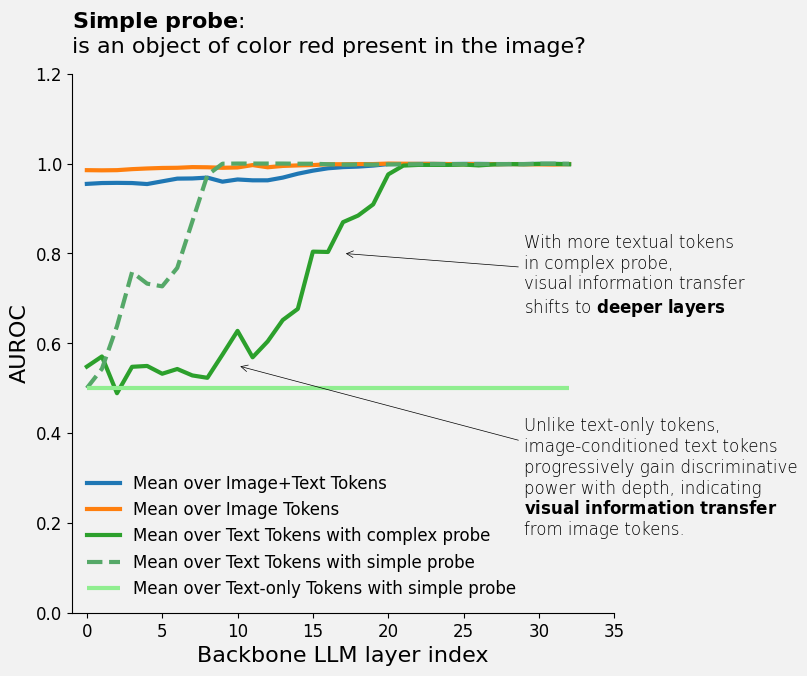

In [7]:
# results_path = '../../results/llava-1.5-7b/linear_probing/archive/image/'

results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/'
metric = 'auroc'

prompt_type = 'complex'
task = ['color']
target = 'red'
nobjects = 3

fig,axs = plt.subplots(
    nrows=1, 
    ncols=1, 
    figsize=(7, 7)
)

axs = [axs]
hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens with {prompt_type} probe',
    'img': 'Mean over Image Tokens'
}

print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df['layer'] = list(range(33))*6
plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)

############
prompt_type = 'simple'
hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens with {prompt_type} probe',
    'img': 'Mean over Image Tokens'
}
print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df_ = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df_['layer'] = list(range(33))*6
plot_df_['embedding over'] = plot_df_['embedding_level'].apply(lambda x: x.split('_')[0])
plot_df_['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df_['embedding_level']]
plot_df_ = plot_df_[plot_df_['embedding over']=='sentence'].reset_index(drop=True)
plot_df_ = plot_df_[plot_df_['hue']==f'Mean over Text Tokens with {prompt_type} probe'].reset_index(drop=True)


b = sns.lineplot(
    data=plot_df, 
    ax=axs[0],
    y=metric, 
    x='layer', 
    hue='hue',
    linewidth=3,
)

sns.lineplot(
    data=plot_df_, 
    ax=b,
    y=metric, 
    x='layer', 
    linestyle="--",   # ← THIS is what you want
    # dashes=True,
    color=sns.color_palette("deep")[2], 
    linewidth=3,
    label=f'Mean over Text Tokens with {prompt_type} probe',
)

b.hlines(
    y=0.5, 
    xmin=0,
    xmax=32,
    color='lightgreen', 
    label='Mean over Text-only Tokens with simple probe',
    linewidth=3,
)

b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
b.set_ylabel(metric.upper(), fontsize=fontsize)

b.set(ylim=(0,1.2), xlim=(-1, 35))

b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.set_title(
    # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
    (
        rf"$\bf{{Simple}}$ $\bf{{probe}}$:"
        "\n"
        f"is an object of {task[0]} {target} present in the image?"
    ),
    loc='left',
    fontsize=fontsize,
    pad=15
)


b.legend(
    frameon=False, 
    fontsize=fontsize_minor,
)

# plt.subplots_adjust(hspace=0.3, wspace=0.3)


axs[0].annotate(
    text=(
        "With more textual tokens\n"
        "in complex probe,\n"
        "visual information transfer\n" 
        rf"shifts to $\bf{{deeper}}$ $\bf{{layers}}$"
        # "Text-only and image-conditioned text\n"
        # r"tokens $\bf{overlap}$"
    ),
    xy=(17, 0.8),          # overlapping region
    xytext=(29, 0.75),
    arrowprops=dict(
        arrowstyle="->", 
        lw=0.5,
        # relpos=(0.4, 0.25), 
    ),
    fontsize=fontsize_minor,
    fontweight=299,
    ha="left",
    va="center",
)

axs[0].annotate(
    text=(
        "Unlike text-only tokens,\n" 
        "image-conditioned text tokens\n"
        "progressively gain discriminative\n" 
        "power with depth, indicating\n"
        r"$\bf{visual}$ $\bf{information}$ $\bf{transfer}$"
        "\nfrom image tokens."
    ),
    xy=(10, 0.55),          # overlapping region
    xytext=(29, 0.3),
    arrowprops=dict(
        arrowstyle="->", 
        lw=0.5,
        # relpos=(0.4, 0.25), 
    ),
    fontsize=fontsize_minor,
    fontweight=299,
    ha="left",
    va="center",
)




axs[0].set_facecolor((0.95, 0.95, 0.95))


# ############For ssimple and complex comparison

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/LP_red_main.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_blue_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_blue_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_gray_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_gray_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_green_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_green_3.csv


/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: se

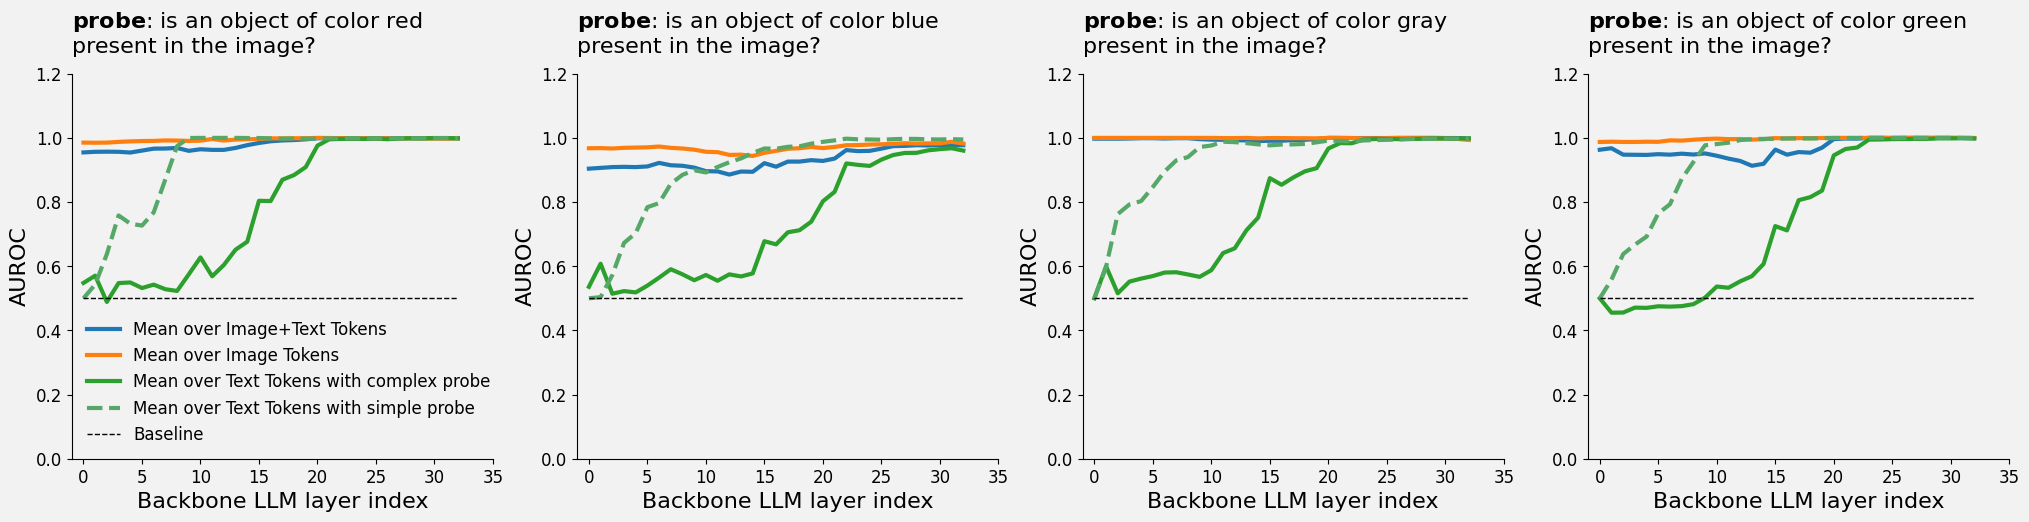

In [86]:
results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/complex/'


# task_ls = ['color']
# target_ls = ['red', 'blue', 'gray', 'green']
# savefigname = 'LP_supp1'

task_ls = ['color_shape']
target_ls = ['blue_cylinder', 'gray_cylinder', 'red_cube', 'green_cube']
savefigname = 'LP_supp2'

nobjects = 3

fig,axs = plt.subplots(
    nrows=1, 
    ncols=4, 
    figsize=(25, 5)
)

for idx, (task, target) in enumerate(list(itertools.product(task_ls, target_ls))):
    results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/'
    metric = 'auroc'
    
    prompt_type = 'complex'
    
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    
    print(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    ############
    prompt_type = 'simple'
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    print(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df_ = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df_['layer'] = list(range(33))*6
    plot_df_['embedding over'] = plot_df_['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df_['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df_['embedding_level']]
    plot_df_ = plot_df_[plot_df_['embedding over']=='sentence'].reset_index(drop=True)
    plot_df_ = plot_df_[plot_df_['hue']==f'Mean over Text Tokens with {prompt_type} probe'].reset_index(drop=True)
    
    
    b = sns.lineplot(
        data=plot_df, 
        ax=axs[idx],
        y=metric, 
        x='layer', 
        hue='hue',
        linewidth=3,
    )
    
    sns.lineplot(
        data=plot_df_, 
        ax=b,
        y=metric, 
        x='layer', 
        linestyle="--",   # ← THIS is what you want
        # dashes=True,
        color=sns.color_palette("deep")[2], 
        linewidth=3,
        label=f'Mean over Text Tokens with {prompt_type} probe',
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=32,
        color='black', 
        label='Baseline',
        linestyle='--',
        linewidth=1,
    )
    
    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 35))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    if 'supp1' in figsavename:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{probe}}$: is an object of {task} {target}"
                "\n"
                f"present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )
    elif 'supp2' in figsavename:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{probe}}$: is an object of {task.split('_')[0]} {target.split('_')[0]}"
                "\n"
                f"and {task.split('_')[1]} {target.split('_')[1]} present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )

    
    if idx==0:
        b.legend(
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()
    
    # plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))


# ############For ssimple and complex comparison

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    f"./../Figures/{savefigname}.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



/tmp/ipykernel_284828/3975529471.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3975529471.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/3975529471.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3975529471.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


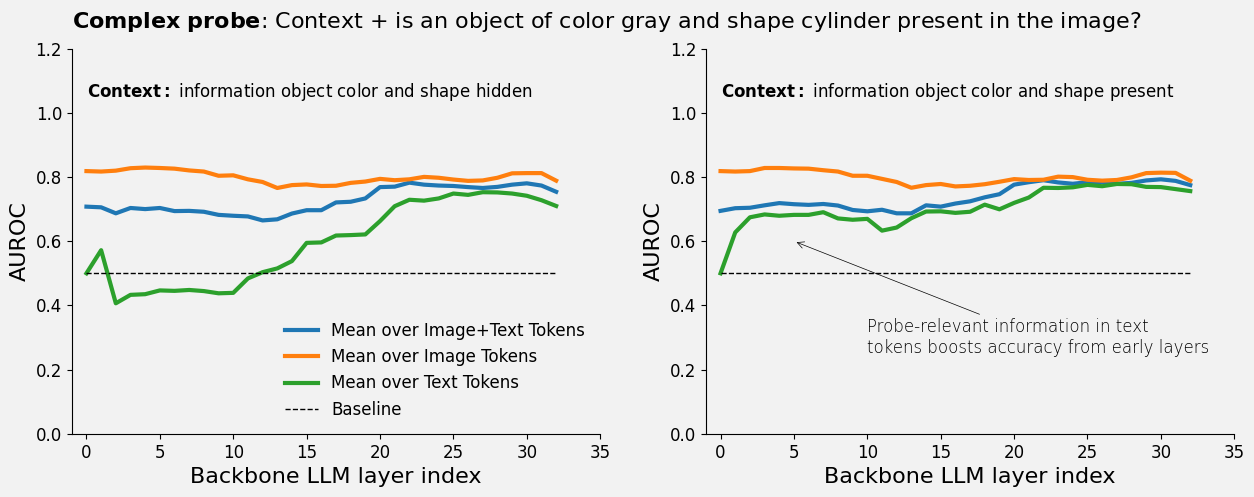

In [91]:
# results_path = '../../results/llava-1.5-7b/linear_probing/archive/image/'

metric = 'auroc'

fig,axs = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(15, 5)
)

results_paths = [
    '../../results/llava-1.5-7b/linear_probing/probe_image/complex/probing_results_color_shape_gray_cylinder_7.csv',
    '../../results/llava-1.5-7b/linear_probing/probe_image_and_text/complex/probing_results_color_shape_gray_cylinder_7.csv'
]

hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens',
    'img': 'Mean over Image Tokens'
}

for idx, results_path in enumerate(results_paths):
    
    plot_df = pd.read_csv(results_path)
    plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    b = sns.lineplot(
        data=plot_df, 
        y=metric, 
        x='layer', 
        hue='hue',
        ax=axs[idx],
        linewidth=3,
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=32,
        linestyle='--',
        color='black', 
        label='Baseline',
        linewidth=1,
    )
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))


    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 35))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )


    if idx==0:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{Complex}}$ $\bf{{probe}}$: Context + is an object of color gray and shape cylinder present in the image?"
                # "\n"
                # f"is an object of color gray and shape cylinder present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )
        
        b.legend(
            loc='lower right',
            frameon=False, 
            fontsize=fontsize_minor,
        )

        axs[idx].text(
            0.02, 1.1,
            rf"$\bf{{Context:}}$ information object color and shape hidden",
            fontsize=fontsize_minor,
            va="top",
        )
            
    elif idx==1:

        axs[idx].text(
            0.02, 1.1,
            rf"$\bf{{Context:}}$ information object color and shape present",
            fontsize=fontsize_minor,
            va="top",
        )
        
        b.legend_.remove()
    


    axs[idx].set_facecolor((0.95, 0.95, 0.95))

axs[1].annotate(
    text=(
        "Probe-relevant information in text\n"
        "tokens boosts accuracy from early layers"
    ),
    xy=(5, 0.6),          # overlapping region
    xytext=(10, 0.3),
    arrowprops=dict(
        arrowstyle="->", 
        lw=0.5,
        # relpos=(0.4, 0.25), 
    ),
    fontsize=fontsize_minor,
    fontweight=299,
    ha="left",
    va="center",
)

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/LP_text_image_supp.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: se

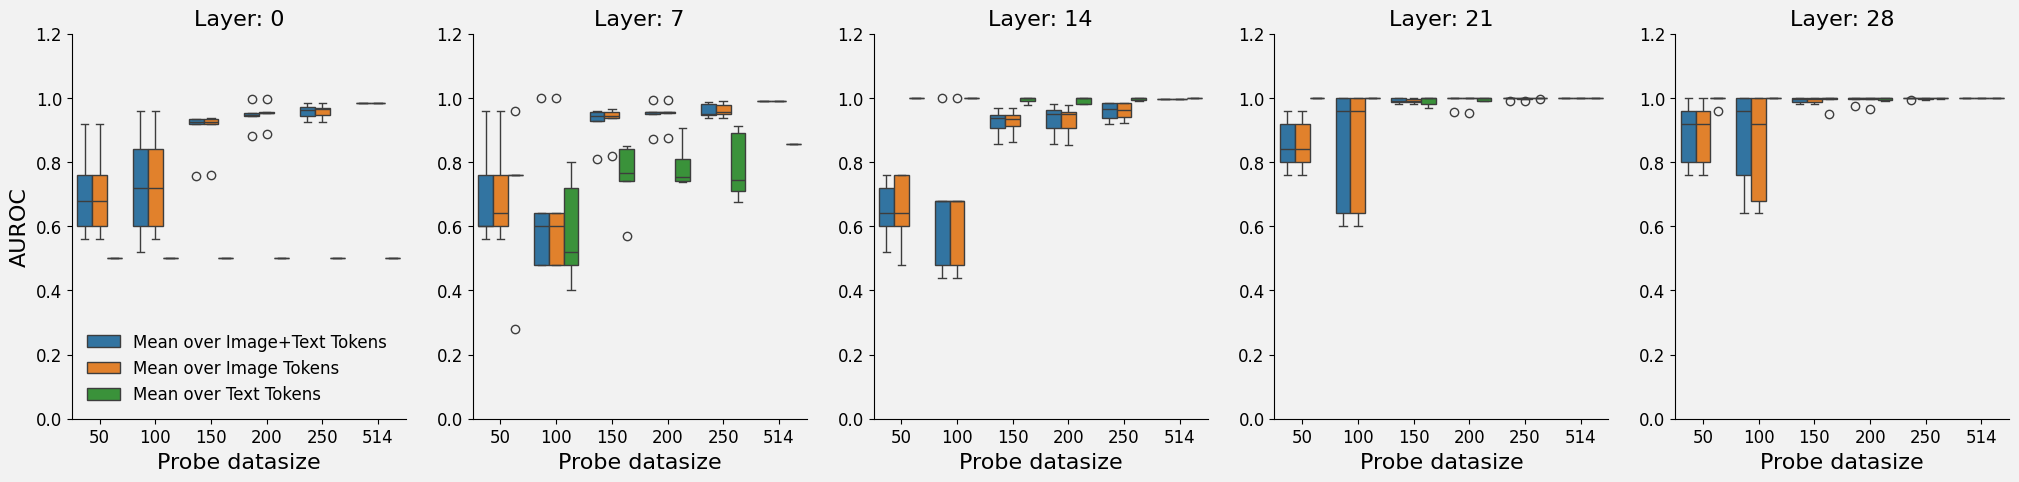

In [111]:
datasize_ls = [50,100,150,200,250,514]
layers = list(range(0,33,7))
metric = 'auroc'
prompt_type = ['simple', 'complex']
task = 'color'
target = 'red'
nobjects = 3

hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens',
    'img': 'Mean over Image Tokens'
}

fig,axs = plt.subplots(nrows=1, ncols=len(layers), figsize=(5*len(layers), 5))

plot_simple_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'../../results/llava-1.5-7b/linear_probing/probe_size/{prompt_type[0]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_simple_df = plot_simple_df + [df]
plot_simple_df = pd.concat(plot_simple_df)
plot_simple_df['embedding over'] = plot_simple_df['embedding_level'].apply(lambda x: x.split('_')[0])
plot_simple_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_simple_df['embedding_level']]

plot_complex_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'../../results/llava-1.5-7b/linear_probing/probe_size/{prompt_type[1]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_complex_df = plot_complex_df + [df]
plot_complex_df = pd.concat(plot_complex_df)
plot_complex_df['embedding over'] = plot_complex_df['embedding_level'].apply(lambda x: x.split('_')[0])


for idx, layer in enumerate(layers):
    b = sns.boxplot(
        data=plot_simple_df[(plot_simple_df['layer']==layer) & (plot_simple_df['embedding over']=='sentence')], 
        ax=axs[idx],
        y=metric, 
        x='probe_datasize', 
        hue='hue',
    )
    b.set(ylim=(0,1.2))
    b.set_title(f"Layer: {layer}", fontsize=fontsize)
    
    b.set_xlabel('Probe datasize', fontsize=fontsize)

    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )
    
    if idx==0:
        b.legend(
            frameon=False, 
            fontsize=fontsize_minor
        )
        b.set_ylabel(metric.upper(), fontsize=fontsize)
    else:
        b.legend_.remove()
        b.set_ylabel('', fontsize=fontsize)
    axs[idx].set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

plt.subplots_adjust(hspace=0.3)

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/LP_probe_datasize_supp.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



In [113]:
results_path = '../../results/llava-1.5-7b/linear_probing/probe_size/complex/probing_results_color_red_3_datasize_514.csv'
# [i for i in os.listdir(results_path+'/complex/') if 'vlm' in i]
pd.read_csv(results_path)

,Unnamed: 0,accuracy,auroc,auprc,f1,precision,recall,embedding_level,layer,k
0,0,0.873786,0.950603,0.954254,0.873786,0.865385,0.882353,sentence_all,0,0
1,1,0.902913,0.965309,0.965295,0.903846,0.886792,0.921569,sentence_all,7,0
2,2,0.912621,0.980015,0.981366,0.910891,0.920000,0.901961,sentence_all,14,0
3,3,0.990291,0.999623,0.999623,0.990099,1.000000,0.980392,sentence_all,21,0
4,4,0.990291,0.999246,0.999260,0.990099,1.000000,0.980392,sentence_all,28,0
...,...,...,...,...,...,...,...,...,...,...
145,0,0.495146,0.441176,0.451350,0.662338,0.495146,1.000000,token_text,0,4
146,1,0.407767,0.410633,0.431612,0.419048,0.407407,0.431373,token_text,7,4
147,2,0.446602,0.424962,0.433553,0.457143,0.444444,0.470588,token_text,14,4
148,3,0.514563,0.509804,0.523136,0.528302,0.509091,0.549020,token_text,21,4


eRank(text)  = 54.48
eRank(vision) = 6.37
Gap (text - vision) = 48.11


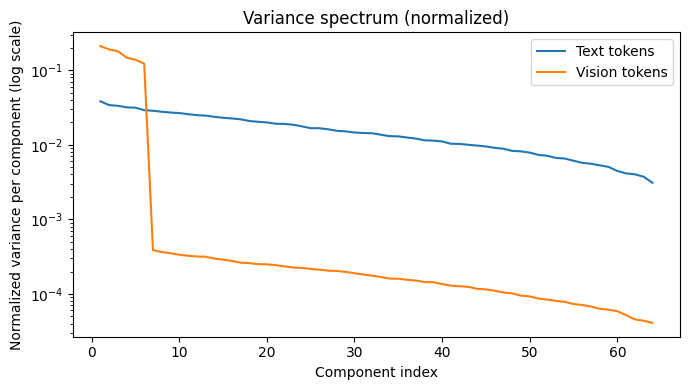

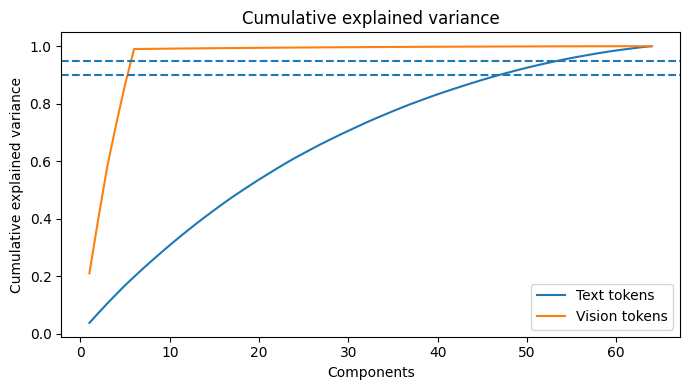

k90 text/vision: 47 6
k95 text/vision: 54 6


In [94]:
import numpy as np
import matplotlib.pyplot as plt

def effective_rank_from_embeddings(E, eps=1e-12):
    """
    E: (n_tokens, d) embedding matrix (tokens x hidden_dim)
    Returns: erank, p (normalized variance spectrum), s (singular values)
    """
    # Center across tokens (important for spectrum)
    X = E - E.mean(axis=0, keepdims=True)

    # SVD on token matrix gives variance directions in feature space
    # singular values s relate to explained variance: v_i ∝ s_i^2
    s = np.linalg.svd(X, full_matrices=False, compute_uv=False)
    v = (s ** 2) + eps
    p = v / v.sum()  # normalized variance distribution

    # Effective rank = exp(entropy(p))
    H = -np.sum(p * np.log(p + eps))
    erank = float(np.exp(H))
    return erank, p, s

def plot_spectrum_and_cdf(p_txt, p_vis, title="Variance spectrum (normalized)"):
    k = np.arange(1, len(p_txt) + 1)

    # Spectrum
    plt.figure(figsize=(7, 4))
    plt.plot(k, p_txt, label="Text tokens")
    plt.plot(k, p_vis, label="Vision tokens")
    plt.yscale("log")  # makes low eRank pop visually
    plt.xlabel("Component index")
    plt.ylabel("Normalized variance per component (log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CDF
    cdf_txt = np.cumsum(p_txt)
    cdf_vis = np.cumsum(p_vis)

    plt.figure(figsize=(7, 4))
    plt.plot(k, cdf_txt, label="Text tokens")
    plt.plot(k, cdf_vis, label="Vision tokens")
    plt.axhline(0.90, linestyle="--")
    plt.axhline(0.95, linestyle="--")
    plt.xlabel("Components")
    plt.ylabel("Cumulative explained variance")
    plt.title("Cumulative explained variance")
    plt.legend()
    plt.tight_layout()
    plt.show()

def k_for_threshold(cdf, thr):
    return int(np.searchsorted(cdf, thr) + 1)

# ---- Example usage ----
import numpy as np

np.random.seed(0)

# dimensions
d = 64
n_txt = 200
n_vis = 200

# --- Text embeddings: isotropic variance ---
E_txt = np.random.randn(n_txt, d)

# --- Vision embeddings: variance concentrated in k dims ---
k = 6  # effective dimensionality
E_vis = np.zeros((n_vis, d))
E_vis[:, :k] = np.random.randn(n_vis, k) * 3.0   # strong variance
E_vis[:, k:] = np.random.randn(n_vis, d - k) * 0.1  # weak variance


er_txt, p_txt, _ = effective_rank_from_embeddings(E_txt)
er_vis, p_vis, _ = effective_rank_from_embeddings(E_vis)

print(f"eRank(text)  = {er_txt:.2f}")
print(f"eRank(vision) = {er_vis:.2f}")
print(f"Gap (text - vision) = {er_txt - er_vis:.2f}")

plot_spectrum_and_cdf(p_txt, p_vis)

# Optional: annotate k90/k95
cdf_txt = np.cumsum(p_txt); cdf_vis = np.cumsum(p_vis)
print("k90 text/vision:", k_for_threshold(cdf_txt, 0.90), k_for_threshold(cdf_vis, 0.90))
print("k95 text/vision:", k_for_threshold(cdf_txt, 0.95), k_for_threshold(cdf_vis, 0.95))


eRank(text)  = 54.48
eRank(vision) = 6.37
Gap (text - vision) = 48.11


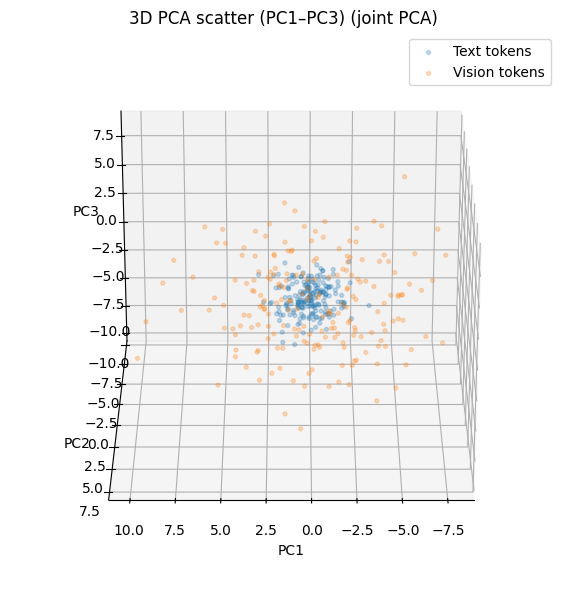

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def pca_fit(X):
    """Return mean and top-3 PCA directions using SVD."""
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    V3 = Vt[:3]  # (3, d)
    return mu, V3

def pca_project(E, mu, V3):
    """Project embeddings onto the shared PCA basis."""
    return (E - mu) @ V3.T  # (n,3)

def plot_3d_pca_scatter(E_txt, E_vis, title="3D PCA scatter (PC1–PC3)", joint=True, max_points=5000):
    """
    E_txt: (n_txt, d)
    E_vis: (n_vis, d)
    joint=True fits PCA on combined data (recommended for fair comparison).
    max_points subsamples for speed/clarity.
    """
    # optional subsample for plotting clarity
    rng = np.random.default_rng(0)
    if E_txt.shape[0] > max_points:
        E_txt = E_txt[rng.choice(E_txt.shape[0], max_points, replace=False)]
    if E_vis.shape[0] > max_points:
        E_vis = E_vis[rng.choice(E_vis.shape[0], max_points, replace=False)]

    if joint:
        X = np.vstack([E_txt, E_vis])
        mu, V3 = pca_fit(X)
    else:
        # fit on text only (sometimes useful, but less fair)
        mu, V3 = pca_fit(E_txt)

    Z_txt = pca_project(E_txt, mu, V3)
    Z_vis = pca_project(E_vis, mu, V3)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Z_txt[:, 0], Z_txt[:, 1], Z_txt[:, 2], s=8, alpha=0.25, label="Text tokens")
    ax.scatter(Z_vis[:, 0], Z_vis[:, 1], Z_vis[:, 2], s=8, alpha=0.25, label="Vision tokens")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title + (" (joint PCA)" if joint else " (PCA fit on text)"))
    ax.view_init(elev=25, azim=90)  # 🔁 rotate here
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- usage ---
#



import numpy as np

np.random.seed(0)

# dimensions
d = 64
n_txt = 200
n_vis = 200

# --- Text embeddings: isotropic variance ---
E_txt = np.random.randn(n_txt, d)

# --- Vision embeddings: variance concentrated in k dims ---
k = 6  # effective dimensionality
E_vis = np.zeros((n_vis, d))
E_vis[:, :k] = np.random.randn(n_vis, k) * 3.0   # strong variance
E_vis[:, k:] = np.random.randn(n_vis, d - k) * 0.1  # weak variance


er_txt, p_txt, _ = effective_rank_from_embeddings(E_txt)
er_vis, p_vis, _ = effective_rank_from_embeddings(E_vis)

print(f"eRank(text)  = {er_txt:.2f}")
print(f"eRank(vision) = {er_vis:.2f}")
print(f"Gap (text - vision) = {er_txt - er_vis:.2f}")
plot_3d_pca_scatter(E_txt, E_vis, joint=True)